In [1]:
# Dependencias fornecidas pelo venv local (.venv-notebook).


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')


In [3]:
from pathlib import Path
import os

persisted_csv_path = Path('./dados_de_persistencia/roteador/data.csv')
runtime_csv_path = Path(f"/tmp/docker_lab_{os.getenv('USER', '')}/roteador/data.csv")
FIGURES_DIR = Path('./relatorio_figuras')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_current_figure(filename):
    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, bbox_inches='tight', dpi=200)
    print(f'Figura atualizada em: {output_path}')

if persisted_csv_path.exists():
    csv_path = persisted_csv_path
elif runtime_csv_path.exists():
    csv_path = runtime_csv_path
    print('Aviso: usando CSV temporario do /tmp; para analise reproduzivel, prefira copiar o arquivo para dados_de_persistencia/roteador/data.csv.')
else:
    raise FileNotFoundError('Nao encontrei data.csv em dados_de_persistencia nem no /tmp do lab ativo.')

print(f'Lendo CSV de: {csv_path}')
data = pd.read_csv(csv_path)


Lendo CSV de: dados_de_persistencia/roteador/data.csv


In [4]:
data.head()

,flow_id,time_sec,total_packages,total_bytes,bps,pps,window_start_sec,window_end_sec,window_duration_s,protocol,service,direction,traffic_class,decision,signature_name,payload_textual_packets,payload_binary_packets,payload_empty_packets,payload_markers,payload_examples
0,other-nginx,105.0,12,1920,384.0,2.4,100.0,105.0,5.0,TCP,nginx,other,normal,forwarded,NaN,0,12,0,binary_repeated_x|low_entropy_payload,NaN
1,attacker-nginx,105.0,17,2720,544.0,3.4,100.0,105.0,5.0,TCP,nginx,attacker_to_server,anomalous,blocked,hping3_repeated_x_burst,0,17,0,binary_repeated_x|low_entropy_payload,NaN
2,attacker-nginx,110.0,28,4480,896.0,5.6,105.0,110.0,5.0,TCP,nginx,attacker_to_server,anomalous,blocked,hping3_repeated_x_burst,0,28,0,binary_repeated_x|low_entropy_payload,NaN
3,other-nginx,110.0,20,3200,640.0,4.0,105.0,110.0,5.0,TCP,nginx,other,normal,forwarded,NaN,0,20,0,binary_repeated_x|low_entropy_payload,NaN
4,attacker-nginx,115.0,25,4000,800.0,5.0,110.0,115.0,5.0,TCP,nginx,attacker_to_server,anomalous,blocked,hping3_repeated_x_burst,0,25,0,binary_repeated_x|low_entropy_payload,NaN


Figura atualizada em: relatorio_figuras/figura_1_bps_fluxo.png


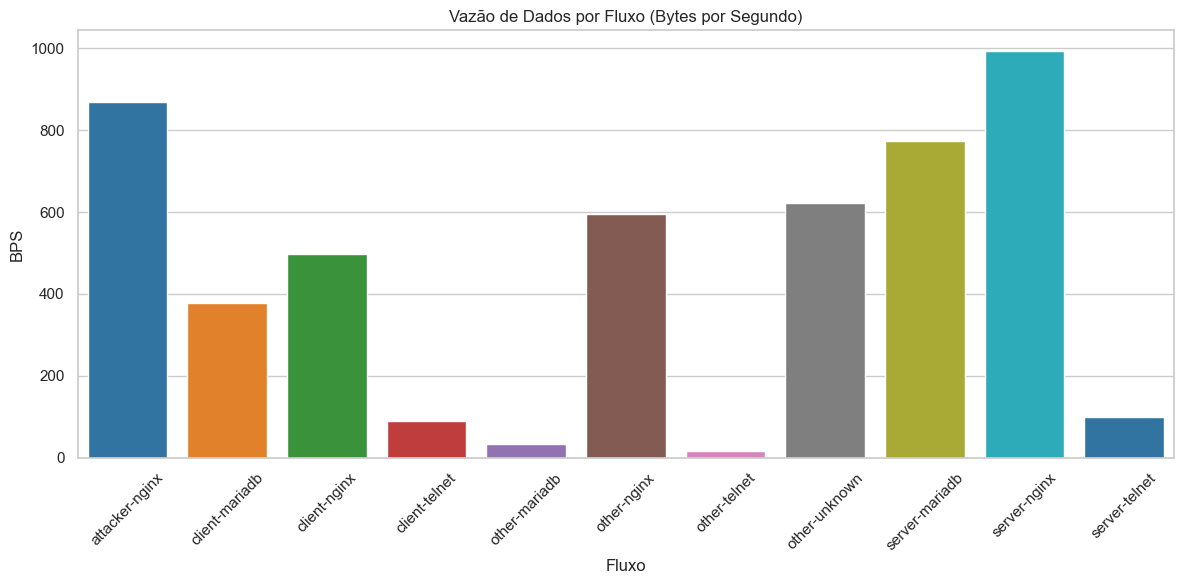

In [5]:
# --- GRÁFICO 1: Vazão por fluxo (BPS ponderado pela duração da janela) ---
flow_summary = (
    data.groupby(['flow_id', 'service', 'direction', 'traffic_class'], as_index=False)
    .agg(
        total_bytes=('total_bytes', 'sum'),
        total_packages=('total_packages', 'sum'),
        window_duration_s=('window_duration_s', 'sum'),
    )
)
flow_summary['bps'] = flow_summary['total_bytes'] / flow_summary['window_duration_s']
flow_summary['pps'] = flow_summary['total_packages'] / flow_summary['window_duration_s']
flow_summary = flow_summary.sort_values('flow_id')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=flow_summary, x='flow_id', y='bps', hue='flow_id', dodge=False, palette='tab10')
if ax.legend_ is not None:
    ax.legend_.remove()
plt.title('Vazão de Dados por Fluxo (Bytes por Segundo)')
plt.xticks(rotation=45)
plt.ylabel('BPS')
plt.xlabel('Fluxo')
plt.tight_layout()
save_current_figure('figura_1_bps_fluxo.png')
plt.show()


Figura atualizada em: relatorio_figuras/figura_2_pps_fluxo.png


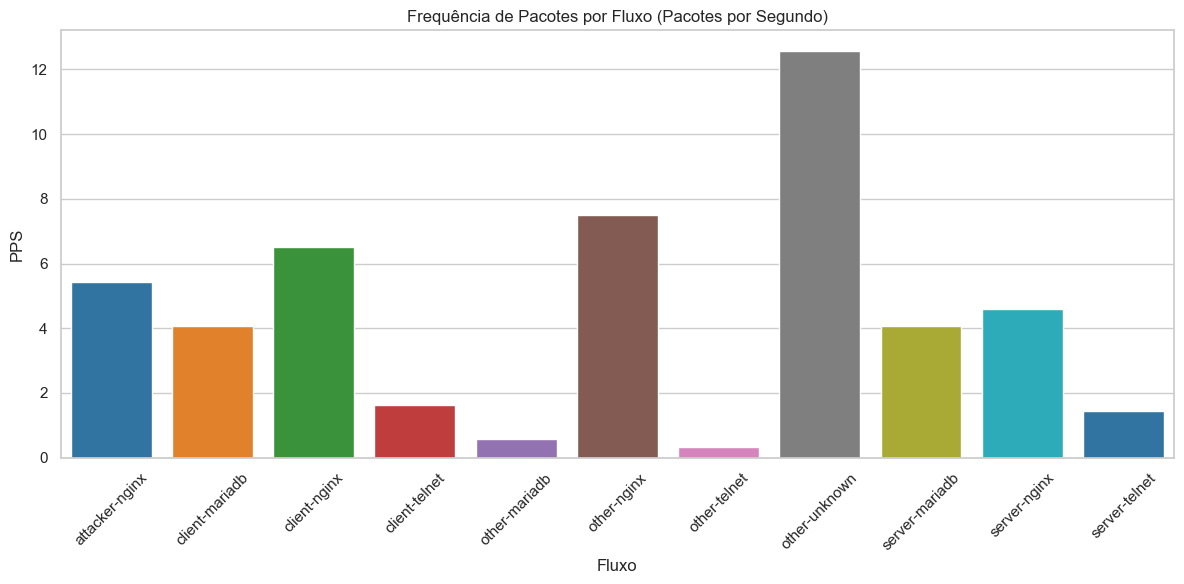

In [6]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=flow_summary, x='flow_id', y='pps', hue='flow_id', dodge=False, palette='tab10')
if ax.legend_ is not None:
    ax.legend_.remove()
plt.title('Frequência de Pacotes por Fluxo (Pacotes por Segundo)')
plt.xticks(rotation=45)
plt.ylabel('PPS')
plt.xlabel('Fluxo')
plt.tight_layout()
save_current_figure('figura_2_pps_fluxo.png')
plt.show()


In [7]:
data

,flow_id,time_sec,total_packages,total_bytes,bps,pps,window_start_sec,window_end_sec,window_duration_s,protocol,service,direction,traffic_class,decision,signature_name,payload_textual_packets,payload_binary_packets,payload_empty_packets,payload_markers,payload_examples
0,other-nginx,105.000,12,1920,384.000,2.400,100.0,105.000,5.000,TCP,nginx,other,normal,forwarded,NaN,0,12,0,binary_repeated_x|low_entropy_payload,NaN
1,attacker-nginx,105.000,17,2720,544.000,3.400,100.0,105.000,5.000,TCP,nginx,attacker_to_server,anomalous,blocked,hping3_repeated_x_burst,0,17,0,binary_repeated_x|low_entropy_payload,NaN
2,attacker-nginx,110.000,28,4480,896.000,5.600,105.0,110.000,5.000,TCP,nginx,attacker_to_server,anomalous,blocked,hping3_repeated_x_burst,0,28,0,binary_repeated_x|low_entropy_payload,NaN
3,other-nginx,110.000,20,3200,640.000,4.000,105.0,110.000,5.000,TCP,nginx,other,normal,forwarded,NaN,0,20,0,binary_repeated_x|low_entropy_payload,NaN
4,attacker-nginx,115.000,25,4000,800.000,5.000,110.0,115.000,5.000,TCP,nginx,attacker_to_server,anomalous,blocked,hping3_repeated_x_burst,0,25,0,binary_repeated_x|low_entropy_payload,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,client-mariadb,1160.000,40,3716,743.200,8.000,1155.0,1160.000,5.000,TCP,mariadb,client_to_server,normal,forwarded,NaN,0,35,5,NaN,NaN
977,server-mariadb,1160.000,39,7469,1493.800,7.800,1155.0,1160.000,5.000,TCP,mariadb,server_to_client,normal,forwarded,NaN,0,35,4,NaN,NaN
978,other-nginx,1163.804,37,1480,389.090,9.727,1160.0,1163.804,3.804,TCP,nginx,other,normal,forwarded,NaN,0,0,37,NaN,NaN
979,client-telnet,1163.804,11,619,162.734,2.892,1160.0,1163.804,3.804,TCP,telnet,client_to_server,normal,forwarded,NaN,1,6,4,telnet_username_aluno,aluno\n


Resumo de observacao de payload:


,categoria,pacotes_observados
0,payload_textual_packets,1021
1,payload_binary_packets,7652
2,payload_empty_packets,17465


Assinaturas bloqueadas:


,signature_name,janelas_bloqueadas
0,hping3_repeated_x_burst,44


Marcadores de payload mais frequentes:


,payload_marker,ocorrencias
0,http_get,97
1,binary_repeated_x,88
2,low_entropy_payload,88
3,telnet_username_aluno,71
4,telnet_command_ls,64
5,telnet_password_lab123,63


Exemplos de payload textual observados:


,payload_example
0,aluno\n
1,Password:
2,lab123\n
3,ls -la\nexit\n
4,\r\n
5,Ubuntu 22.04.5 LTS\r\n52fe180b83f5 login:
6,Welcome to Ubuntu 22.04.5 LTS (GNU/Linux 6.12....
7,GET / HTTP/1.1\r\nHost: 10.0.1.2\r\nUser-Agent...


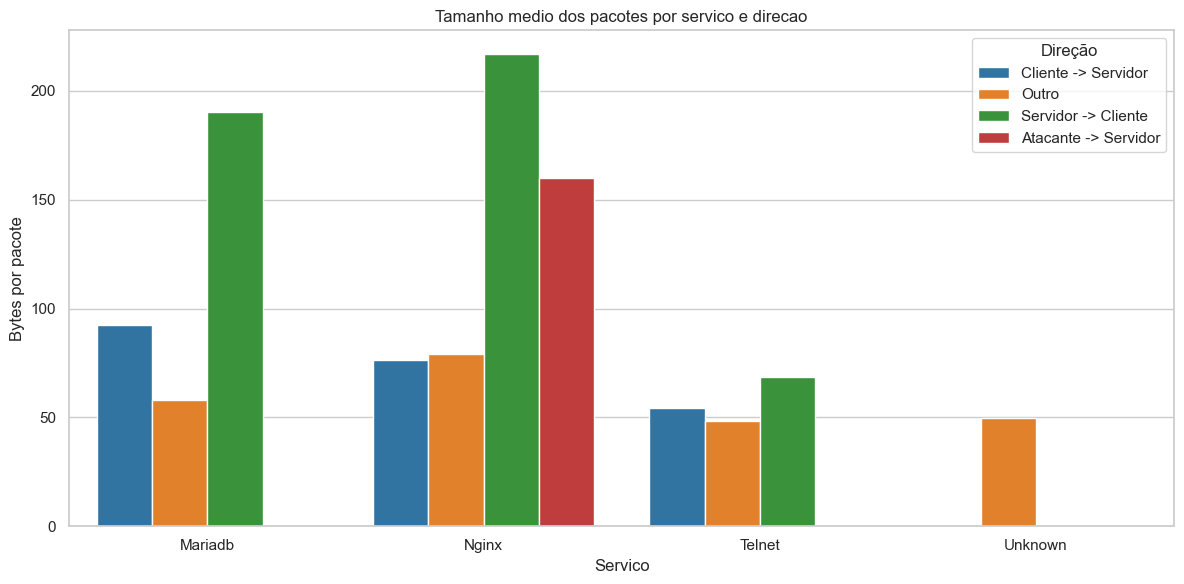

In [8]:
# Criar colunas extras sem descartar trafego legitimo
data = data.copy()
data['signature_name'] = data['signature_name'].fillna('')

for column in ['payload_markers', 'payload_examples']:
    if column not in data.columns:
        data[column] = ''
    data[column] = data[column].fillna('')

for column in ['payload_textual_packets', 'payload_binary_packets', 'payload_empty_packets']:
    if column not in data.columns:
        data[column] = 0
    data[column] = pd.to_numeric(data[column], errors='coerce').fillna(0).astype(int)

data['Direção'] = data['direction'].map({
    'server_to_client': 'Servidor -> Cliente',
    'client_to_server': 'Cliente -> Servidor',
    'attacker_to_server': 'Atacante -> Servidor',
    'other': 'Outro'
}).fillna(data['direction'])
data['Serviço'] = data['service'].fillna('unknown').str.capitalize()
data['Classe'] = data['traffic_class'].map({
    'normal': 'Normal',
    'anomalous': 'Anômalo'
}).fillna(data['traffic_class'])
data['Decisão'] = data['decision'].map({
    'forwarded': 'Encaminhado',
    'blocked': 'Bloqueado'
}).fillna(data['decision'])

payload_observation_summary = pd.DataFrame({
    'categoria': ['payload_textual_packets', 'payload_binary_packets', 'payload_empty_packets'],
    'pacotes_observados': [
        int(data['payload_textual_packets'].sum()),
        int(data['payload_binary_packets'].sum()),
        int(data['payload_empty_packets'].sum()),
    ],
})

blocked_signature_summary = (
    data.loc[data['decision'] == 'blocked', 'signature_name']
    .replace('', pd.NA)
    .dropna()
    .value_counts()
    .rename_axis('signature_name')
    .reset_index(name='janelas_bloqueadas')
)

payload_marker_summary = (
    data['payload_markers']
    .str.split('|')
    .explode()
    .replace('', pd.NA)
    .dropna()
    .value_counts()
    .rename_axis('payload_marker')
    .reset_index(name='ocorrencias')
)

payload_examples = (
    data['payload_examples']
    .str.split(' || ', regex=False)
    .explode()
    .replace('', pd.NA)
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

print('Resumo de observacao de payload:')
display(payload_observation_summary)

print('Assinaturas bloqueadas:')
display(blocked_signature_summary)

print('Marcadores de payload mais frequentes:')
display(payload_marker_summary.head(10))

print('Exemplos de payload textual observados:')
display(payload_examples.to_frame(name='payload_example').head(10))

# Janelas muito curtas aparecem no flush parcial do roteador e distorcem os scatterplots.
plot_data = data[data['window_duration_s'] >= 1].copy()

service_direction_summary = (
    data.groupby(['Serviço', 'Direção'], as_index=False)
    .agg(
        total_bytes=('total_bytes', 'sum'),
        total_packages=('total_packages', 'sum'),
    )
)
service_direction_summary['avg_packet_size'] = (
    service_direction_summary['total_bytes'] / service_direction_summary['total_packages']
)
service_direction_summary = service_direction_summary.sort_values(['Serviço', 'Direção'])

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=service_direction_summary, x='Serviço', y='avg_packet_size', hue='Direção', palette='tab10')
plt.title('Tamanho medio dos pacotes por servico e direcao')
plt.ylabel('Bytes por pacote')
plt.xlabel('Servico')
plt.tight_layout()
plt.show()



Figura atualizada em: relatorio_figuras/figura_3_scatter_bytes_pacotes.png


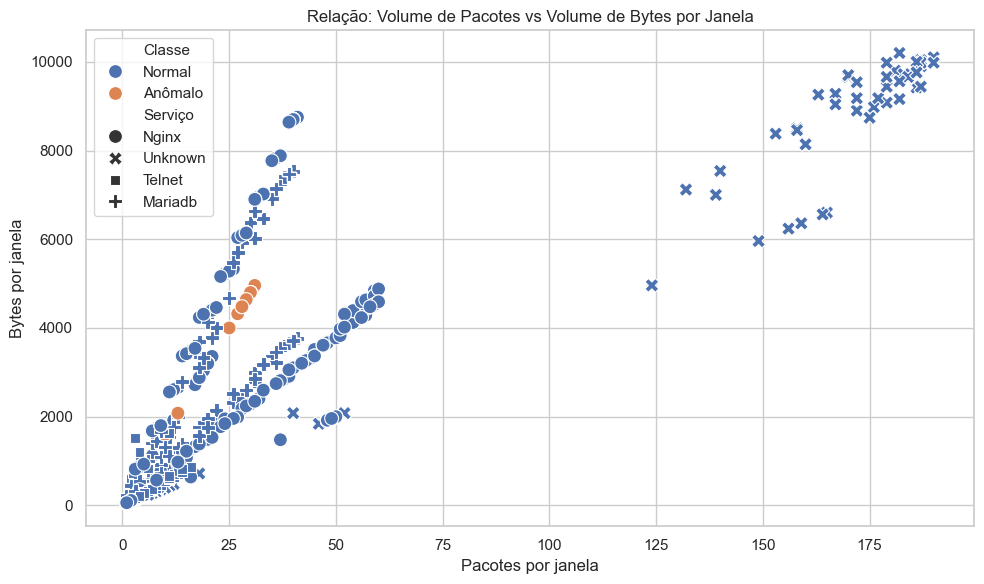

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data, x='total_packages', y='total_bytes', hue='Classe', style='Serviço', s=100)
plt.title('Relação: Volume de Pacotes vs Volume de Bytes por Janela')
plt.xlabel('Pacotes por janela')
plt.ylabel('Bytes por janela')
plt.tight_layout()
save_current_figure('figura_3_scatter_bytes_pacotes.png')
plt.show()


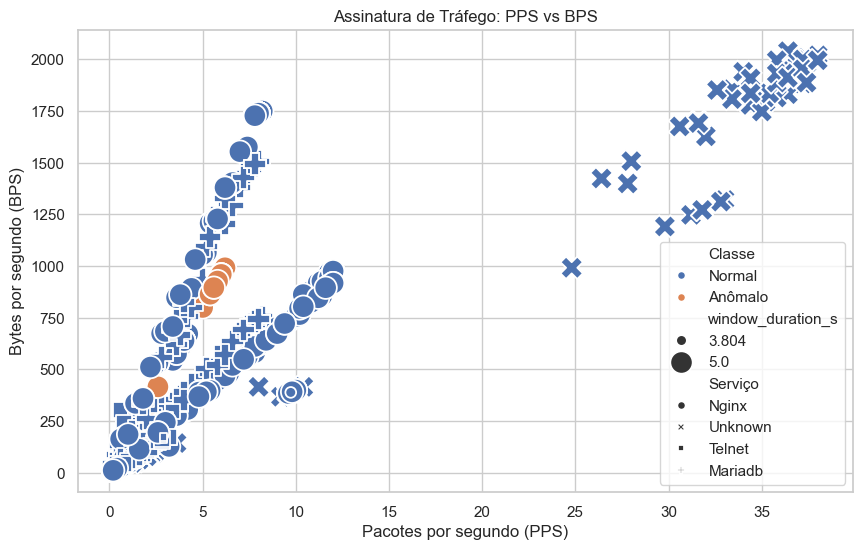

Figura atualizada em: relatorio_figuras/figura_4_painel_comparativo.png


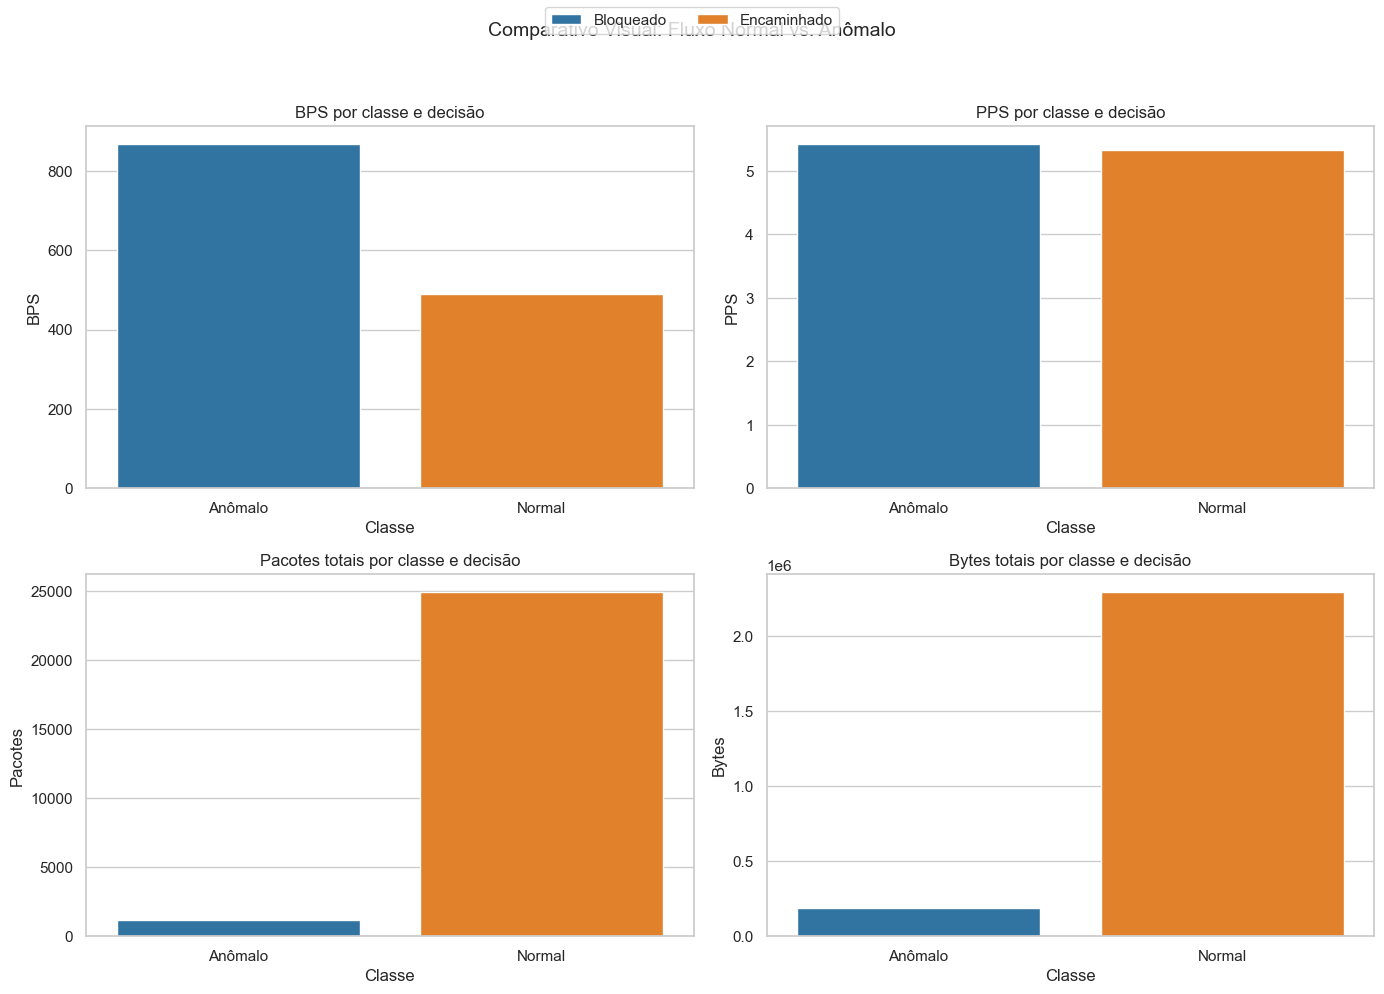

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data, x='pps', y='bps', hue='Classe', style='Serviço', size='window_duration_s', sizes=(60, 260))
plt.title("Assinatura de Tráfego: PPS vs BPS")
plt.xlabel('Pacotes por segundo (PPS)')
plt.ylabel('Bytes por segundo (BPS)')
plt.show()

comparison_summary = (
    plot_data.groupby(['Classe', 'Decisão'], as_index=False)
    .agg(
        total_bytes=('total_bytes', 'sum'),
        total_packages=('total_packages', 'sum'),
        window_duration_s=('window_duration_s', 'sum'),
    )
)
comparison_summary['bps'] = comparison_summary['total_bytes'] / comparison_summary['window_duration_s']
comparison_summary['pps'] = comparison_summary['total_packages'] / comparison_summary['window_duration_s']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=comparison_summary, x='Classe', y='bps', hue='Decisão', ax=axes[0, 0], palette='tab10')
axes[0, 0].set_title('BPS por classe e decisão')
axes[0, 0].set_xlabel('Classe')
axes[0, 0].set_ylabel('BPS')

sns.barplot(data=comparison_summary, x='Classe', y='pps', hue='Decisão', ax=axes[0, 1], palette='tab10')
axes[0, 1].set_title('PPS por classe e decisão')
axes[0, 1].set_xlabel('Classe')
axes[0, 1].set_ylabel('PPS')

sns.barplot(data=comparison_summary, x='Classe', y='total_packages', hue='Decisão', ax=axes[1, 0], palette='tab10')
axes[1, 0].set_title('Pacotes totais por classe e decisão')
axes[1, 0].set_xlabel('Classe')
axes[1, 0].set_ylabel('Pacotes')

sns.barplot(data=comparison_summary, x='Classe', y='total_bytes', hue='Decisão', ax=axes[1, 1], palette='tab10')
axes[1, 1].set_title('Bytes totais por classe e decisão')
axes[1, 1].set_xlabel('Classe')
axes[1, 1].set_ylabel('Bytes')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=0)

handles, labels = axes[0, 0].get_legend_handles_labels()
for ax in axes.flat:
    if ax.legend_ is not None:
        ax.legend_.remove()
fig.legend(handles, labels, loc='upper center', ncol=2)
fig.suptitle('Comparativo Visual: Fluxo Normal vs. Anômalo', fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIGURES_DIR / 'figura_4_painel_comparativo.png', bbox_inches='tight', dpi=200)
print(f'Figura atualizada em: {FIGURES_DIR / "figura_4_painel_comparativo.png"}')
plt.show()
